# Quantitative Momentum — Final Replication
**Gray & Vogel (2016), Chapters 5–8**

| Parameter | Specification |
|---|---|
| Universe | NYSE/AMEX/NASDAQ, market cap > NYSE 40th percentile breakpoint |
| Filters | Ordinary common equity; exclude financials (SIC 6000-6999) & utilities (4900-4999) |
| Generic Momentum | 12-month cumulative total return, skip most recent month (12-1) |
| FIP Formula | `sign(past_return) × [%negative_days − %positive_days]` over past 252 days |
| FIP Interpretation | More negative = smoother path = BETTER |
| Selection | Top 10% by momentum → top 50% of those by FIP |
| Weights | Value-weighted (book's Table 8.2 headline results) |
| Rebalance | End of Feb, May, Aug, Nov (smart seasonality) |
| Fees | 1.80% annual (1% mgmt + 0.45% × 4 rebalances) |
| Benchmark | S&P 500 total return (`sprtrn` from CRSP) |

**Expected results (book Table 8.2, 1927–2014, net of fees):**

| | QM | Generic Mom | S&P 500 |
|---|---|---|---|
| CAGR | 15.80% | 13.45% | 9.92% |
| Sharpe | 0.60 | 0.51 | 0.41 |
| Worst DD | -76.97% | -75.81% | -84.59% |

## 0. Configuration

In [44]:
# ─────────────────────────────────────────────────────────────────
# CONFIGURATION — edit these before running
# ─────────────────────────────────────────────────────────────────

DEMO = False   # True = 2006-2013 (fast validation); False = full 1963-2013

# Paths
DAILY_ZIP   = r"C:\Users\danie\Desktop\AlgoTrading\WRDS_DATASETS\CRSP [done]\2. Stock (V2 CIZ)\1. Daily Stock File\kldpywkoe50talt6_csv.zip"
BASE_DIR    = r"C:\Users\danie\Downloads\algo_trading\quantitative_momentum\data"

PARQUET_OUT = BASE_DIR + (r"\crsp_daily_demo.parquet" if DEMO else r"\crsp_daily_full.parquet")

# Date ranges
FULL_START  = "1963-01-01"
FULL_END    = "2013-12-31"
DEMO_START  = "2006-01-01"   # last 8 years — full pipeline validation
DEMO_END    = "2013-12-31"

START_DATE  = DEMO_START if DEMO else FULL_START
END_DATE    = DEMO_END   if DEMO else FULL_END

# Strategy parameters
TOP_DECILE_PCT    = 0.10   # top 10% by momentum
FIP_KEEP_FRAC     = 0.50   # top 50% of top decile by FIP
REBALANCE_MONTHS  = [2, 5, 8, 11]   # end of Feb, May, Aug, Nov
ANNUAL_FEE        = 0.018  # 1.80% per year
DAILY_FEE         = ANNUAL_FEE / 252

# Signal windows (in trading days)
LOOKBACK_DAYS     = 252    # ~12 months
SKIP_DAYS         = 21     # ~1 month to skip
MIN_DAYS          = 180    # minimum valid days in window

# SIC exclusions
SIC_FIN_LO, SIC_FIN_HI  = 6000, 6999
SIC_UTIL_LO, SIC_UTIL_HI = 4900, 4999

# CRSP dlycap is in thousands of dollars
DLYCAP_MULT = 1_000

print(f"Mode       : {'DEMO' if DEMO else 'FULL'}")
print(f"Date range : {START_DATE} → {END_DATE}")
print(f"Parquet    : {PARQUET_OUT}")

Mode       : FULL
Date range : 1963-01-01 → 2013-12-31
Parquet    : C:\Users\danie\Downloads\algo_trading\quantitative_momentum\data\crsp_daily_full.parquet


## 1. Imports

In [45]:
import os
import zipfile
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path
import time

warnings.filterwarnings("ignore")
os.makedirs(BASE_DIR, exist_ok=True)

KEEP_COLS = [
    "PERMNO", "DlyCalDt", "DlyRet", "DlyCap", "DlyPrc",
    "SICCD", "PrimaryExch", "SecurityActiveFlg",
    "IssuerType", "ShareType", "sprtrn",
]

print("Imports OK")

Imports OK


## 2. Build Parquet (run once)
Reads raw CSV in 500K-row chunks, filters on the fly, saves compressed parquet. Delete the parquet file to rebuild.

In [46]:
if Path(PARQUET_OUT).exists():
    print(f"Parquet exists — skipping rebuild.\n  {PARQUET_OUT}")
else:
    print(f"Building parquet ({'DEMO' if DEMO else 'FULL'}: {START_DATE} → {END_DATE})...")
    t0 = time.time()
    writer = None
    total_rows = 0

    with zipfile.ZipFile(DAILY_ZIP) as zf:
        csv_name = [f for f in zf.namelist() if f.endswith(".csv")][0]
        with zf.open(csv_name) as f:
            for chunk in pd.read_csv(
                f,
                usecols=KEEP_COLS,
                chunksize=500_000,
                dtype={
                    "PERMNO": "int32",
                    "DlyRet": "float32",
                    "DlyCap": "float32",
                    "DlyPrc": "float32",
                    "SICCD":  "Int16",
                    "sprtrn": "float32",
                },
                parse_dates=["DlyCalDt"],
                low_memory=False,
            ):
                # Filter date range
                chunk = chunk[
                    (chunk["DlyCalDt"] >= START_DATE) &
                    (chunk["DlyCalDt"] <= END_DATE)
                ]
                # Active stocks only (point-in-time)
                chunk = chunk[chunk["SecurityActiveFlg"] == "Y"]

                if len(chunk) == 0:
                    continue

                table = pa.Table.from_pandas(chunk, preserve_index=False)
                if writer is None:
                    writer = pq.ParquetWriter(PARQUET_OUT, table.schema, compression="snappy")
                writer.write_table(table)
                total_rows += len(chunk)
                print(f"  {total_rows:,} rows written...", end="\r")

    if writer:
        writer.close()
    print(f"\n  Done. {total_rows:,} rows in {time.time()-t0:.1f}s")
    print(f"  Saved: {PARQUET_OUT}")

Building parquet (FULL: 1963-01-01 → 2013-12-31)...
  74,965,415 rows written...
  Done. 74,965,415 rows in 771.8s
  Saved: C:\Users\danie\Downloads\algo_trading\quantitative_momentum\data\crsp_daily_full.parquet


In [47]:
# ── DEBUG: verify parquet contents ──
_check = pd.read_parquet(PARQUET_OUT)
_check.columns = [c.lower() for c in _check.columns]
print(f"Parquet row count: {len(_check):,}")
print("Exchange breakdown in parquet:")
print(_check["primaryexch"].value_counts())
print(f"Date range: {_check['dlycaldt'].min().date()} → {_check['dlycaldt'].max().date()}")
del _check

Parquet row count: 74,965,415
Exchange breakdown in parquet:
primaryexch
Q    37709892
N    24790841
A    11120011
R     1336510
B        8161
Name: count, dtype: int64
Date range: 1963-01-02 → 2013-12-31


## 3. Load & Clean

In [49]:
# ── Cell 3: Load & filter universe ───────────────────────────────────
print("Loading parquet...")
t0 = time.time()
df = pd.read_parquet(PARQUET_OUT)
df.columns = [c.lower() for c in df.columns]
print(f"  {len(df):,} rows in {time.time()-t0:.1f}s")

# Diagnostics
print(f"\n  issuertype values: {df['issuertype'].value_counts().to_dict()}")
print(f"  sharetype values:  {df['sharetype'].value_counts().to_dict()}")
print(f"  primaryexch values: {df['primaryexch'].value_counts().to_dict()}")

# Market cap in dollars
df["mktcap"] = df["dlycap"] * DLYCAP_MULT

# Ordinary common equity: ACOR *or* CORP are both valid corporations
df = df[df["issuertype"].isin(["ACOR", "CORP"])]
df = df[df["sharetype"] == "NS"]

# Keep only NYSE, AMEX, NASDAQ
df = df[df["primaryexch"].isin(["N", "A", "Q"])]

# Exclude financials and utilities
is_fin  = (df["siccd"] >= SIC_FIN_LO)  & (df["siccd"] <= SIC_FIN_HI)
is_util = (df["siccd"] >= SIC_UTIL_LO) & (df["siccd"] <= SIC_UTIL_HI)
df = df[~is_fin & ~is_util]

# Drop rows with missing return or market cap
df = df.dropna(subset=["dlyret", "mktcap"])

# Sort for rolling calculations
df = df.sort_values(["permno", "dlycaldt"]).reset_index(drop=True)

print(f"\n  After filters: {len(df):,} rows, {df['permno'].nunique():,} stocks")
print(f"  Date range: {df['dlycaldt'].min().date()} → {df['dlycaldt'].max().date()}")

Loading parquet...
  74,965,415 rows in 92.9s

  issuertype values: {'CORP': 52935045, 'ACOR': 20448131, 'REIT': 1582239}
  sharetype values:  {'NS': 69690052, 'AD': 2493152, 'SB': 2018236, 'UG': 726638, 'CE': 37337}
  primaryexch values: {'Q': 37709892, 'N': 24790841, 'A': 11120011, 'R': 1336510, 'B': 8161}

  After filters: 50,741,606 rows, 20,360 stocks
  Date range: 1963-01-02 → 2013-12-31


## 4. Vectorized Signal Computation

Precompute **all signals on all stocks on all days** using rolling windows — fast, no per-stock loops.

- **Momentum (12-1):** cumulative return over days [t-252, t-22], i.e. 12 months minus most recent month
- **FIP:** `sign(12m return) × (%negative_days − %positive_days)` over past 252 days. Lower = smoother = better.

In [50]:
print("Computing signals (vectorized)...")
t0 = time.time()

# Log return for compounding
df["log_ret"] = np.log1p(df["dlyret"])

# Day flags for FIP
df["pos_day"] = (df["dlyret"] > 0).astype("int8")
df["neg_day"] = (df["dlyret"] < 0).astype("int8")

grp = df.groupby("permno")

# Full 252-day cumulative log return
df["logret_252"] = grp["log_ret"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).sum()
)
# Recent 21-day cumulative log return (to subtract for 12-1 skip)
df["logret_21"] = grp["log_ret"].transform(
    lambda x: x.rolling(SKIP_DAYS, min_periods=SKIP_DAYS).sum()
)
# Momentum (12-1) = 12m return minus most recent month
df["mom_12_1"] = np.expm1(df["logret_252"] - df["logret_21"])

# FIP components over full 252 days
df["pos_252"] = grp["pos_day"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).sum()
)
df["neg_252"] = grp["neg_day"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).sum()
)
df["cnt_252"] = grp["log_ret"].transform(
    lambda x: x.rolling(LOOKBACK_DAYS, min_periods=MIN_DAYS).count()
)

df["pct_pos"] = df["pos_252"] / df["cnt_252"]
df["pct_neg"] = df["neg_252"] / df["cnt_252"]

# Full 12m return for the sign component of FIP
df["ret_12m"] = np.expm1(df["logret_252"])

# FIP = sign(12m return) * (%negative - %positive)
# More negative = smoother upward path = BETTER
df["fip"] = np.sign(df["ret_12m"]) * (df["pct_neg"] - df["pct_pos"])

print(f"  Signals computed in {time.time()-t0:.1f}s")
print(f"  Rows with valid momentum: {df['mom_12_1'].notna().sum():,}")
print(f"  Rows with valid FIP:      {df['fip'].notna().sum():,}")
print(f"\n  Momentum stats:")
print(df["mom_12_1"].describe().to_string())
print(f"\n  FIP stats (more negative = better):")
print(df["fip"].describe().to_string())

Computing signals (vectorized)...
  Signals computed in 61.3s
  Rows with valid momentum: 47,158,833
  Rows with valid FIP:      47,158,833

  Momentum stats:
count    4.715883e+07
mean     1.406966e-01
std      7.850370e-01
min     -9.996194e-01
25%     -2.525850e-01
50%      2.812179e-02
75%      3.455937e-01
max      1.116448e+02

  FIP stats (more negative = better):
count    4.715883e+07
mean    -3.433120e-02
std      5.643136e-02
min     -3.809524e-01
25%     -6.746032e-02
50%     -3.174603e-02
75%      0.000000e+00
max      3.134921e-01


## 5. NYSE 40th Percentile Size Screen

Compute the 40th percentile of market cap using **NYSE stocks only**, apply to all exchanges. Fama-French convention.

In [51]:
print("Computing NYSE 40th percentile size breakpoints...")
df["ym"] = df["dlycaldt"].dt.to_period("M")
# Check what exchanges exist
print("Exchange values:", df["primaryexch"].value_counts().head())
print("ym dtype:", df["ym"].dtype)

# NYSE 40th percentile per month
nyse_bp = (
    df[df["primaryexch"] == "N"]
    .groupby("ym")["mktcap"]
    .quantile(0.40)
    .rename("nyse_p40")
    .reset_index()
)

print(f"nyse_bp shape: {nyse_bp.shape}")
print(f"nyse_bp dtypes: {nyse_bp.dtypes}")
print(nyse_bp.head(3))

Computing NYSE 40th percentile size breakpoints...
Exchange values: primaryexch
Q    27688501
N    14857811
A     8195294
Name: count, dtype: int64
ym dtype: period[M]
nyse_bp shape: (612, 2)
nyse_bp dtypes: ym          period[M]
nyse_p40      float64
dtype: object
        ym    nyse_p40
0  1963-01  41217248.0
1  1963-02  41965000.0
2  1963-03  41093500.0


## 6. Build S&P 500 Benchmark

Compound daily `sprtrn` (already in the daily file) to monthly returns.

In [52]:
# sprtrn is the same for all stocks on a given day — take one value per day
sp500_daily = (
    df.groupby("dlycaldt")["sprtrn"]
    .first()
    .reset_index()
    .rename(columns={"sprtrn": "sp_ret"})
)
sp500_daily["ym"] = sp500_daily["dlycaldt"].dt.to_period("M")

# Compound daily → monthly
sp500_monthly = (
    sp500_daily.groupby("ym")["sp_ret"]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
    .rename(columns={"sp_ret": "bench_ret"})
)
sp500_monthly["bench_equity"] = (1 + sp500_monthly["bench_ret"]).cumprod()

print(f"S&P 500 monthly series: {len(sp500_monthly)} months")
print(f"Total S&P 500 return: {sp500_monthly['bench_equity'].iloc[-1]-1:.1%}")

S&P 500 monthly series: 612 months
Total S&P 500 return: 2829.3%


## 7. Rebalance Dates

In [53]:
# Last trading day of Feb, May, Aug, Nov each year
all_dates = df[["dlycaldt", "ym"]].drop_duplicates("dlycaldt")
all_dates["month"] = all_dates["dlycaldt"].dt.month
all_dates["year"]  = all_dates["dlycaldt"].dt.year

rebal_dates = (
    all_dates[all_dates["month"].isin(REBALANCE_MONTHS)]
    .groupby(["year", "month"])["dlycaldt"]
    .max()
    .sort_values()
    .values
)

print(f"Rebalance dates: {len(rebal_dates)}")
print(f"  First: {pd.Timestamp(rebal_dates[0]).date()}")
print(f"  Last:  {pd.Timestamp(rebal_dates[-1]).date()}")

Rebalance dates: 204
  First: 1963-02-28
  Last:  2013-11-29


## 8. Backtest Engine

At each rebalance date:
1. Snapshot of universe (size screen + valid signals)
2. **Generic Mom**: top 10% by `mom_12_1`, value-weighted
3. **QMom**: top 10% by `mom_12_1` → top 50% by FIP (lowest = best), value-weighted
4. Hold until next rebalance, subtract daily fee

In [54]:
"""
# Recompute size screen inline (robust to re-runs)
df["ym"] = df["dlycaldt"].dt.to_period("M")
nyse_bp = (
    df[df["primaryexch"] == "N"]
    .groupby("ym")["mktcap"]
    .quantile(0.40)
    .rename("nyse_p40")
    .reset_index()
)
df = df.merge(nyse_bp, on="ym", how="left")
df["passes_size"] = df["mktcap"] >= df["nyse_p40"]

print("Running backtest...")
t0 = time.time()

# Pre-index for fast lookups
df_idx = df.set_index("dlycaldt")

gm_records   = []   # Generic Momentum daily returns
qm_records   = []   # Quantitative Momentum daily returns
port_info    = {}   # For inspection

for i in range(len(rebal_dates) - 1):
    rdate = pd.Timestamp(rebal_dates[i])
    ndate = pd.Timestamp(rebal_dates[i + 1])

    # ── Snapshot at rebalance date ──────────────────────────────
    snap = df[
        (df["dlycaldt"] == rdate) &
        (df["passes_size"] == True)
    ][["permno", "mom_12_1", "fip", "mktcap"]].dropna()

    if len(snap) < 20:
        continue

    n = len(snap)
    n_top = max(int(n * TOP_DECILE_PCT), 10)

    # ── Generic Momentum: top decile by momentum ────────────────
    top_mom = snap.nlargest(n_top, "mom_12_1")

    # ── QMom: top half of top decile by FIP (ascending = best) ──
    n_qm = max(int(n_top * FIP_KEEP_FRAC), 5)
    top_qm = top_mom.nsmallest(n_qm, "fip")  # lowest FIP = smoothest

    port_info[rdate] = {
        "n_universe": n,
        "n_top_mom":  n_top,
        "n_qm":       n_qm,
        "avg_mom":    top_qm["mom_12_1"].mean(),
        "avg_fip":    top_qm["fip"].mean(),
    }

    # ── Holding period daily returns ─────────────────────────────
    hold = df[
        (df["dlycaldt"] > rdate) &
        (df["dlycaldt"] <= ndate)
    ][["dlycaldt", "permno", "dlyret", "mktcap"]].copy()

    if hold.empty:
        continue

    def vw_daily_ret(hold_df, formation_snap):
        """Value-weighted daily portfolio return using formation-date weights."""
        permnos = formation_snap["permno"].tolist()
        weights = formation_snap.set_index("permno")["mktcap"]
        weights = weights / weights.sum()

        h = hold_df[hold_df["permno"].isin(permnos)].copy()
        h["w"] = h["permno"].map(weights).fillna(0)

        daily = (
            h.groupby("dlycaldt")
            .apply(lambda g: (g["dlyret"] * g["w"]).sum() / g["w"].sum())
            .reset_index(name="ret")
        )
        daily["ret"] -= DAILY_FEE
        return daily

    gm_daily = vw_daily_ret(hold, top_mom)
    qm_daily = vw_daily_ret(hold, top_qm)

    gm_daily["period"] = rdate
    qm_daily["period"] = rdate

    gm_records.append(gm_daily)
    qm_records.append(qm_daily)

gm_results = pd.concat(gm_records).sort_values("dlycaldt").reset_index(drop=True)
qm_results = pd.concat(qm_records).sort_values("dlycaldt").reset_index(drop=True)

gm_results["equity"] = (1 + gm_results["ret"]).cumprod()
qm_results["equity"] = (1 + qm_results["ret"]).cumprod()

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  GM: {len(gm_results):,} daily obs, final equity: {gm_results['equity'].iloc[-1]:.2f}x")
print(f"  QM: {len(qm_results):,} daily obs, final equity: {qm_results['equity'].iloc[-1]:.2f}x")
"""

MemoryError: Unable to allocate 387. MiB for an array with shape (1, 50741606) and data type float64

In [56]:
import sys
import gc

# Check dataframe memory
print("=== DATAFRAME ===")
print(f"df shape: {df.shape}")
print(f"df memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print("\nPer column:")
print((df.memory_usage(deep=True) / 1e6).sort_values(ascending=False).head(20).to_string())

# Check all variables in memory
print("\n=== ALL LARGE VARIABLES (>50MB) ===")
large = {}
for name, obj in list(globals().items()):
    try:
        size = sys.getsizeof(obj)
        if size > 50 * 1024 * 1024:
            large[name] = size
    except:
        pass
for name, size in sorted(large.items(), key=lambda x: -x[1]):
    print(f"  {name:<30} {size/1e9:.2f} GB")

# Check garbage
print(f"\nGarbage collector: {gc.get_count()}")

=== DATAFRAME ===
df shape: (50741606, 26)
df memory: 18.52 GB

Per column:
issuertype           3095.237966
sharetype            2993.754754
primaryexch          2943.013148
securityactiveflg    2943.013148
ym                    405.932848
logret_252            405.932848
fip                   405.932848
dlycaldt              405.932848
ret_12m               405.932848
pct_neg               405.932848
pct_pos               405.932848
cnt_252               405.932848
neg_252               405.932848
pos_252               405.932848
mom_12_1              405.932848
logret_21             405.932848
log_ret               202.966424
permno                202.966424
mktcap                202.966424
sprtrn                202.966424

=== ALL LARGE VARIABLES (>50MB) ===
  df                             18.52 GB
  df_idx                         2.69 GB
  sample                         0.96 GB
  is_fin                         0.67 GB
  is_util                        0.67 GB
  nyse               

In [57]:
import gc

# Delete cached variables no longer needed
del df_idx, sample, is_fin, is_util, nyse
gc.collect()

# Trim df to only what backtest needs
keep = ["permno", "dlycaldt", "dlyret", "mktcap", "primaryexch", "mom_12_1", "fip"]
df = df[keep].copy()
gc.collect()

print(f"df shape: {df.shape}")
print(f"df memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Check remaining large vars
import sys
print("\nRemaining large variables (>50MB):")
for name, obj in sorted(globals().items(), key=lambda x: sys.getsizeof(x[1]), reverse=True)[:10]:
    try:
        size = sys.getsizeof(obj)
        if size > 50 * 1024 * 1024:
            print(f"  {name:<30} {size/1e9:.2f} GB")
    except:
        pass

df shape: (50741606, 7)
df memory: 4.77 GB

Remaining large variables (>50MB):
  df                             4.77 GB


In [60]:
import gc
import numpy as np

# ── Memory cleanup ───────────────────────────────────────────────
keep = ["permno", "dlycaldt", "dlyret", "mktcap", "primaryexch", "mom_12_1", "fip"]
df = df[[c for c in keep if c in df.columns]].copy()
gc.collect()
print(f"df trimmed: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# ── Size screen via map (no merge) ───────────────────────────────
df["ym"] = df["dlycaldt"].dt.to_period("M")
nyse_p40 = (
    df[df["primaryexch"] == "N"]
    .groupby("ym")["mktcap"]
    .quantile(0.40)
)
df["passes_size"] = df["mktcap"].values >= df["ym"].map(nyse_p40).values
gc.collect()
print(f"df after size screen: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# ── Pre-group by date ONCE ───────────────────────────────────────
print("Pre-indexing by date...")
t0 = time.time()

# For snapshots: only size-passing rows, only signal cols
snap_cols = ["permno", "mom_12_1", "fip", "mktcap"]
snap_by_date = {
    date: grp[snap_cols].reset_index(drop=True)
    for date, grp in df[df["passes_size"]][["dlycaldt"] + snap_cols].groupby("dlycaldt")
}

# For holding: only return cols, stored as numpy arrays per date
# dict: date -> (permno_array, dlyret_array, mktcap_array)
hold_by_date = {
    date: (
        grp["permno"].values,
        grp["dlyret"].values,
        grp["mktcap"].values,
    )
    for date, grp in df[["dlycaldt", "permno", "dlyret", "mktcap"]].groupby("dlycaldt")
}

print(f"  Pre-indexed in {time.time()-t0:.1f}s")
print(f"  Snap dates: {len(snap_by_date):,}  Hold dates: {len(hold_by_date):,}")

# ── Backtest ─────────────────────────────────────────────────────
print("Running backtest...")
t0 = time.time()

def vw_ret_numpy(hold_days, permno_set, weight_dict):
    """
    Compute daily VW returns for a holding period.
    hold_days: list of (permno_arr, dlyret_arr, mktcap_arr)
    Returns list of (date, ret) tuples.
    """
    results = []
    for date, (permnos, rets, _) in hold_days:
        mask = np.isin(permnos, permno_set)
        if mask.sum() == 0:
            continue
        p = permnos[mask]
        r = rets[mask]
        w = np.array([weight_dict.get(px, 0.0) for px in p])
        total_w = w.sum()
        if total_w == 0:
            continue
        results.append((date, (r * w).sum() / total_w - DAILY_FEE))
    return results

rebal_list = [pd.Timestamp(d) for d in rebal_dates]
gm_records = []
qm_records = []
port_info  = {}

for i in range(len(rebal_list) - 1):
    rdate = rebal_list[i]
    ndate = rebal_list[i + 1]

    # Snapshot
    snap = snap_by_date.get(rdate)
    if snap is None:
        continue
    snap = snap.dropna()
    if len(snap) < 20:
        continue

    n     = len(snap)
    n_top = max(int(n * TOP_DECILE_PCT), 10)
    n_qm  = max(int(n_top * FIP_KEEP_FRAC), 5)

    top_mom = snap.nlargest(n_top, "mom_12_1")
    top_qm  = top_mom.nsmallest(n_qm, "fip")

    port_info[rdate] = {
        "n_universe": n, "n_top_mom": n_top, "n_qm": n_qm,
        "avg_mom": top_qm["mom_12_1"].mean(),
        "avg_fip": top_qm["fip"].mean(),
    }

    # Build weights dicts
    gm_w = (top_mom.set_index("permno")["mktcap"] / top_mom["mktcap"].sum()).to_dict()
    qm_w = (top_qm.set_index("permno")["mktcap"] / top_qm["mktcap"].sum()).to_dict()
    gm_set = np.array(list(gm_w.keys()))
    qm_set = np.array(list(qm_w.keys()))

    # Holding period days
    hold_days = [
        (d, hold_by_date[d])
        for d in pd.date_range(rdate + pd.offsets.BDay(1), ndate, freq="B")
        if d in hold_by_date
    ]
    if not hold_days:
        continue

    for date, ret in vw_ret_numpy(hold_days, gm_set, gm_w):
        gm_records.append((date, ret))
    for date, ret in vw_ret_numpy(hold_days, qm_set, qm_w):
        qm_records.append((date, ret))

# Assemble results
gm_results = pd.DataFrame(gm_records, columns=["dlycaldt", "ret"]).sort_values("dlycaldt").reset_index(drop=True)
qm_results = pd.DataFrame(qm_records, columns=["dlycaldt", "ret"]).sort_values("dlycaldt").reset_index(drop=True)
gm_results["equity"] = (1 + gm_results["ret"]).cumprod()
qm_results["equity"] = (1 + qm_results["ret"]).cumprod()

print(f"  Done in {time.time()-t0:.1f}s")
print(f"  GM: {len(gm_results):,} obs, final equity: {gm_results['equity'].iloc[-1]:.2f}x")
print(f"  QM: {len(qm_results):,} obs, final equity: {qm_results['equity'].iloc[-1]:.2f}x")

df trimmed: 4.77 GB
df after size screen: 5.23 GB
Pre-indexing by date...
  Pre-indexed in 80.8s
  Snap dates: 12,838  Hold dates: 12,838
Running backtest...
  Done in 5.2s
  GM: 12,587 obs, final equity: 1963.33x
  QM: 12,587 obs, final equity: 3775.65x


## 9. Performance Metrics

In [62]:
def perf_metrics(rets, label, rf_annual=0.035):
    """Daily return series → performance table matching book format."""
    n       = len(rets)
    years   = n / 252
    total   = (1 + rets).prod() - 1
    cagr    = (1 + total) ** (1 / years) - 1
    vol     = rets.std() * np.sqrt(252)
    down_v  = rets[rets < 0].std() * np.sqrt(252)
    sharpe  = (cagr - rf_annual) / vol    if vol   > 0 else np.nan
    sortino = (cagr - 0.05)     / down_v  if down_v > 0 else np.nan
    cum     = (1 + rets).cumprod()
    dd      = (cum / cum.cummax() - 1)
    max_dd  = dd.min()
    # monthly returns
    monthly = rets.groupby(np.arange(len(rets)) // 21).apply(lambda x: (1+x).prod()-1)
    return pd.Series({
        "CAGR":              f"{cagr:.2%}",
        "Std Dev":           f"{vol:.2%}",
        "Downside Dev":      f"{down_v:.2%}",
        "Sharpe (rf=3.5%)": f"{sharpe:.2f}",
        "Sortino (MAR=5%)": f"{sortino:.2f}",
        "Worst DD":          f"{max_dd:.2%}",
        "Worst Month":       f"{monthly.min():.2%}",
        "Best Month":        f"{monthly.max():.2%}",
        "Win Rate (monthly)":f"{(monthly > 0).mean():.2%}",
        "Total Return":      f"{total:.2%}",
        "Years":             f"{years:.1f}",
    }, name=label)

# Align SP500 to backtest period
sp_rets = (
    sp500_daily[
        (sp500_daily["dlycaldt"] >= gm_results["dlycaldt"].min()) &
        (sp500_daily["dlycaldt"] <= gm_results["dlycaldt"].max())
    ]["sp_ret"]
    .reset_index(drop=True)
)

p_gm = perf_metrics(gm_results["ret"],  "Generic Momentum (Net)")
p_qm = perf_metrics(qm_results["ret"],  "QMom — FIP Filtered (Net)")
p_sp = perf_metrics(sp_rets,            "S&P 500")

table = pd.DataFrame([p_qm, p_gm, p_sp]).T
print("\n" + "="*70)
print("PERFORMANCE SUMMARY")
print("="*70)
print(table.to_string())
print("\nBook Table 8.2 (1927-2014, net): QM=15.80% CAGR / Sharpe 0.60 | GenMom=13.45% / 0.51 | SP500=9.92% / 0.41")


PERFORMANCE SUMMARY
                   QMom — FIP Filtered (Net) Generic Momentum (Net)   S&P 500
CAGR                                  17.93%                 16.39%     6.63%
Std Dev                               26.23%                 25.81%    16.34%
Downside Dev                          20.63%                 20.48%    12.59%
Sharpe (rf=3.5%)                        0.55                   0.50      0.19
Sortino (MAR=5%)                        0.63                   0.56      0.13
Worst DD                             -71.96%                -72.96%   -56.78%
Worst Month                          -39.22%                -34.28%   -22.71%
Best Month                            25.80%                 27.00%    15.64%
Win Rate (monthly)                    64.00%                 63.33%    59.50%
Total Return                      377465.45%             196232.71%  2365.99%
Years                                   49.9                   49.9      49.9

Book Table 8.2 (1927-2014, net): QM=15.80%

## 10. Annual Returns Table

In [63]:
gm_results["year"] = gm_results["dlycaldt"].dt.year
qm_results["year"] = qm_results["dlycaldt"].dt.year
sp500_daily["year"] = sp500_daily["dlycaldt"].dt.year

annual = pd.DataFrame({
    "QMom":     qm_results.groupby("year")["ret"].apply(lambda x: (1+x).prod()-1),
    "GenMom":   gm_results.groupby("year")["ret"].apply(lambda x: (1+x).prod()-1),
    "S&P 500":  sp500_daily.groupby("year")["sp_ret"].apply(lambda x: (1+x).prod()-1),
})
annual["QM vs SP500"]  = annual["QMom"] - annual["S&P 500"]
annual["QM vs GenMom"] = annual["QMom"] - annual["GenMom"]

annual_disp = annual.applymap(lambda x: f"{x:.2%}")
print("\n" + "="*75)
print("ANNUAL RETURNS")
print("="*75)
print(annual_disp.to_string())
print(f"\nQM beats S&P 500:  {(annual['QM vs SP500']  > 0).sum()}/{len(annual)} years")
print(f"QM beats GenMom:   {(annual['QM vs GenMom'] > 0).sum()}/{len(annual)} years")


ANNUAL RETURNS
         QMom   GenMom  S&P 500 QM vs SP500 QM vs GenMom
year                                                    
1963    0.99%    1.47%   18.89%     -17.90%       -0.48%
1964   26.21%   16.72%   12.97%      13.24%        9.50%
1965   47.27%   52.17%    9.06%      38.21%       -4.89%
1966   22.83%   16.95%  -13.09%      35.92%        5.88%
1967   49.22%   55.15%   20.09%      29.13%       -5.93%
1968   30.25%   24.09%    7.66%      22.58%        6.15%
1969   -7.56%  -11.25%  -11.36%       3.80%        3.70%
1970   -5.23%   -7.88%    0.10%      -5.33%        2.66%
1971   39.09%   31.11%   10.79%      28.30%        7.98%
1972   44.37%   34.78%   15.63%      28.74%        9.59%
1973   -2.35%   -4.92%  -17.37%      15.02%        2.57%
1974  -26.76%  -27.67%  -29.72%       2.96%        0.91%
1975   33.96%   36.31%   31.55%       2.41%       -2.35%
1976   18.23%   25.67%   19.15%      -0.92%       -7.44%
1977    5.72%   10.18%  -11.50%      17.22%       -4.46%
1978   25.10%  

## 11. Plots

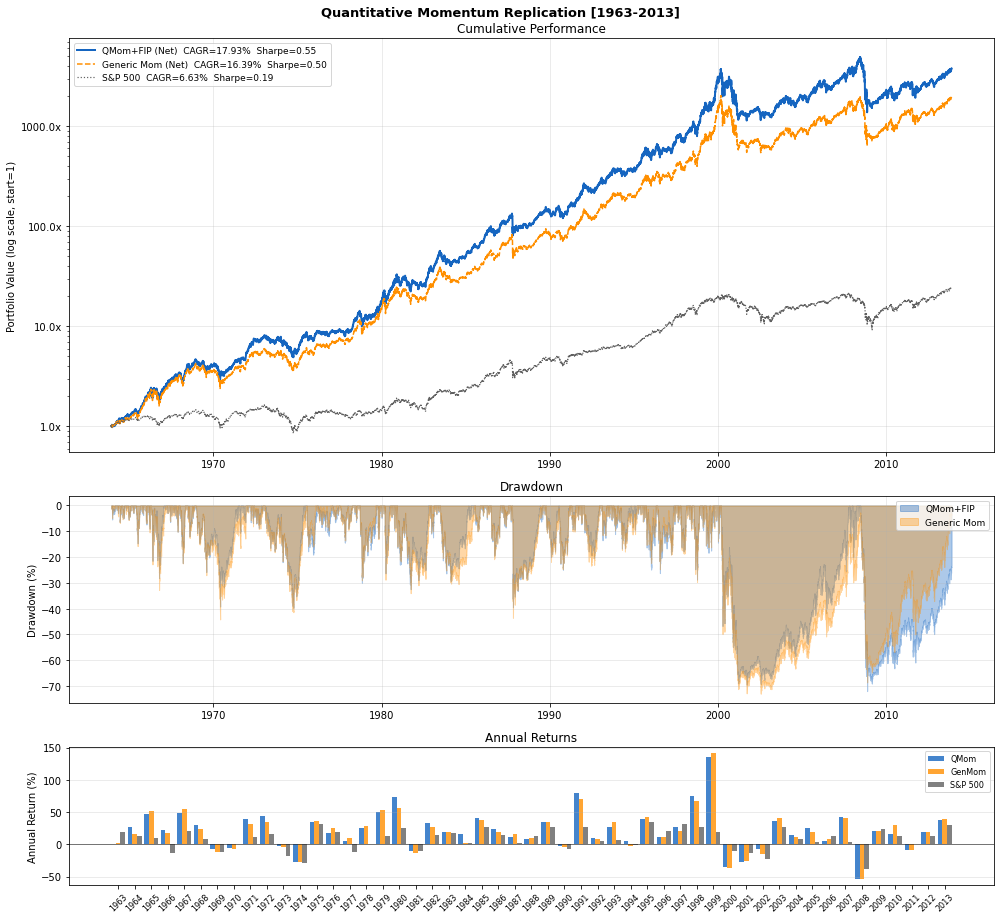

Chart saved: C:\Users\danie\Downloads\algo_trading\quantitative_momentum\data\qm_results.png


In [64]:
# Build S&P 500 equity curve aligned to backtest
sp_bt = sp500_daily[
    (sp500_daily["dlycaldt"] >= gm_results["dlycaldt"].min()) &
    (sp500_daily["dlycaldt"] <= gm_results["dlycaldt"].max())
].copy()
sp_bt["equity"] = (1 + sp_bt["sp_ret"]).cumprod()

fig, axes = plt.subplots(3, 1, figsize=(14, 13),
                         gridspec_kw={"height_ratios": [3, 1.5, 1]})
fig.suptitle(f"Quantitative Momentum Replication {'[DEMO 2006-2013]' if DEMO else '[1963-2013]'}",
             fontsize=13, fontweight="bold")

# ── Panel 1: Cumulative returns ──────────────────────────────────
ax1 = axes[0]
ax1.plot(qm_results["dlycaldt"].values, qm_results["equity"].values,
         label=f"QMom+FIP (Net)  CAGR={p_qm['CAGR']}  Sharpe={p_qm['Sharpe (rf=3.5%)']}",
         color="#1565C0", linewidth=2)
ax1.plot(gm_results["dlycaldt"].values, gm_results["equity"].values,
         label=f"Generic Mom (Net)  CAGR={p_gm['CAGR']}  Sharpe={p_gm['Sharpe (rf=3.5%)']}",
         color="#FF8F00", linewidth=1.5, linestyle="--")
ax1.plot(sp_bt["dlycaldt"].values, sp_bt["equity"].values,
         label=f"S&P 500  CAGR={p_sp['CAGR']}  Sharpe={p_sp['Sharpe (rf=3.5%)']}",
         color="#616161", linewidth=1.2, linestyle=":")
ax1.set_yscale("log")
ax1.set_ylabel("Portfolio Value (log scale, start=1)")
ax1.set_title("Cumulative Performance")
ax1.legend(fontsize=9, loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}x"))

# ── Panel 2: Drawdowns ───────────────────────────────────────────
ax2 = axes[1]
for results_df, label, color in [
    (qm_results, "QMom+FIP",   "#1565C0"),
    (gm_results, "Generic Mom", "#FF8F00"),
]:
    dd = (results_df["equity"] / results_df["equity"].cummax() - 1) * 100
    ax2.fill_between(results_df["dlycaldt"].values, dd.values, 0,
                     alpha=0.35, color=color, label=label)
ax2.set_ylabel("Drawdown (%)")
ax2.set_title("Drawdown")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Panel 3: Annual bars ─────────────────────────────────────────
ax3 = axes[2]
x = np.arange(len(annual))
w = 0.28
ax3.bar(x - w, annual["QMom"].values    * 100, w, color="#1565C0", alpha=0.8, label="QMom")
ax3.bar(x,     annual["GenMom"].values  * 100, w, color="#FF8F00", alpha=0.8, label="GenMom")
ax3.bar(x + w, annual["S&P 500"].values * 100, w, color="#616161", alpha=0.8, label="S&P 500")
ax3.set_xticks(x)
ax3.set_xticklabels(annual.index, rotation=45, fontsize=8)
ax3.axhline(0, color="black", linewidth=0.5)
ax3.set_ylabel("Annual Return (%)")
ax3.set_title("Annual Returns")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
out_path = BASE_DIR + r"\qm_results.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {out_path}")

## 12. Portfolio Inspection

In [65]:
# Average portfolio characteristics over time
info_df = pd.DataFrame(port_info).T
print("Portfolio characteristics over time:")
print(info_df[["n_universe", "n_top_mom", "n_qm", "avg_mom", "avg_fip"]]
      .astype({"n_universe": int, "n_top_mom": int, "n_qm": int})
      .to_string())

print(f"\nAverages:")
print(f"  Universe size:  {info_df['n_universe'].mean():.0f} stocks")
print(f"  Top decile:     {info_df['n_top_mom'].mean():.0f} stocks")
print(f"  After FIP:      {info_df['n_qm'].mean():.0f} stocks")
print(f"  Avg momentum:   {info_df['avg_mom'].mean():.1%}")
print(f"  Avg FIP:        {info_df['avg_fip'].mean():.3f}")

Portfolio characteristics over time:
            n_universe  n_top_mom  n_qm   avg_mom   avg_fip
1963-11-29         644         64    32  0.958533 -0.113035
1964-02-28         650         65    32  1.003424 -0.111303
1964-05-28         655         65    32  0.835448 -0.111359
1964-08-31         647         64    32  0.817309 -0.103919
1964-11-30         649         64    32  0.799440 -0.109003
1965-02-26         665         66    33  0.800250 -0.117761
1965-05-28         659         65    32  1.012136 -0.118474
1965-08-31         682         68    34  0.717759 -0.106092
1965-11-30         685         68    34  1.184731 -0.125000
1966-02-28         682         68    34  1.452144 -0.092670
1966-05-31         672         67    33  1.719198 -0.069264
1966-08-31         661         66    33  1.325117 -0.060847
1966-11-30         692         69    34  0.372405 -0.053805
1967-02-28         677         67    33  0.642679 -0.056878
1967-05-31         666         66    33  1.011658 -0.086340
196

In [68]:
import os
import json

RESULTS_DIR = r"C:\Users\danie\Downloads\algo_trading\quantitative_momentum\results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── 1. Trades CSV — matches PM engine format exactly ────────────
# One row per holding period, portfolio-level aggregated as single "trade"
STARTING_CAPITAL = 100_000.0

trades = []
equity = STARTING_CAPITAL

for i in range(len(rebal_list) - 1):
    rdate = rebal_list[i]
    ndate = rebal_list[i + 1]

    period_rets = qm_results[
        (qm_results["dlycaldt"] > rdate) &
        (qm_results["dlycaldt"] <= ndate)
    ]["ret"]

    if period_rets.empty:
        continue

    pct_return  = (1 + period_rets).prod() - 1
    equity_before = equity
    gross_pnl   = equity_before * pct_return
    fees        = 0
    net_pnl     = gross_pnl - fees
    equity_after = equity_before + net_pnl

    trades.append({
        "entry_time":    rdate.strftime("%Y-%m-%d"),
        "exit_time":     ndate.strftime("%Y-%m-%d"),
        "position":      "long",
        "entry_price":   1.0,               # portfolio-level, no single price
        "exit_price":    round(1 + pct_return, 6),
        "exit_reason":   "rebalance",
        "risk":          0.0,
        "shares":        1,
        "gross_pnl":     round(gross_pnl, 2),
        "fees":          round(fees, 2),
        "net_pnl":       round(net_pnl, 2),
        "equity_before": round(equity_before, 2),
        "equity":        round(equity_after, 2),
    })

    equity = equity_after

trades_df = pd.DataFrame(trades)
trades_path = RESULTS_DIR + r"\qmom_trades.csv"
trades_df.to_csv(trades_path, index=False)
print(f"Trades saved: {len(trades_df)} rows → {trades_path}")
print(trades_df.head(3).to_string())

# ── 2. Daily returns ─────────────────────────────────────────────
daily_path = RESULTS_DIR + r"\qmom_daily.csv"
qm_results[["dlycaldt", "ret", "equity"]].to_csv(daily_path, index=False)
print(f"\nDaily returns saved: {len(qm_results)} rows → {daily_path}")

# ── 3. Monthly returns (for significance tests) ──────────────────
qm_results["ym"] = qm_results["dlycaldt"].dt.to_period("M")
monthly_rets = (
    qm_results.groupby("ym")["ret"]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
    .rename(columns={"ret": "monthly_ret"})
)
monthly_path = RESULTS_DIR + r"\qmom_monthly.csv"
monthly_rets.to_csv(monthly_path, index=False)
print(f"Monthly returns saved: {len(monthly_rets)} rows → {monthly_path}")

# ── 4. Metadata JSON ─────────────────────────────────────────────
metadata = {
    "strategy":     "Quantitative Momentum (QMom)",
    "paper":        "Gray & Vogel (2016) — Quantitative Momentum",
    "universe":     "NYSE/AMEX/NASDAQ, market cap > NYSE 40th percentile",
    "filters":      "Ordinary common equity, excl. financials & utilities",
    "signal":       "12-1 month momentum + FIP quality filter",
    "weighting":    "Value-weighted at formation date",
    "rebalance":    "Quarterly — end of Feb, May, Aug, Nov",
    "fees":         "1.80% annual",
    "period":       "1963-01 to 2013-12",
    "n_trades":     len(trades_df),
    "cagr":         float(p_qm["CAGR"].strip("%")) / 100,
    "sharpe":       float(p_qm["Sharpe (rf=3.5%)"]),
    "max_dd":       float(p_qm["Worst DD"].strip("%")) / 100,
    "total_return": float(p_qm["Total Return"].strip("%")) / 100,
    "ann_vol":      float(p_qm["Std Dev"].strip("%")) / 100,
    "sortino":      float(p_qm["Sortino (MAR=5%)"]),
    "win_rate":     float(p_qm["Win Rate (monthly)"].strip("%")) / 100,
}

meta_path = RESULTS_DIR + r"\qmom_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"\nMetadata saved → {meta_path}")

Trades saved: 200 rows → C:\Users\danie\Downloads\algo_trading\quantitative_momentum\results\qmom_trades.csv
   entry_time   exit_time position  entry_price  exit_price exit_reason  risk  shares  gross_pnl  fees   net_pnl  equity_before     equity
0  1963-11-29  1964-02-28     long          1.0    1.044043   rebalance   0.0       1    4404.27     0   4404.27      100000.00  104404.27
1  1964-02-28  1964-05-28     long          1.0    1.147445   rebalance   0.0       1   15393.91     0  15393.91      104404.27  119798.18
2  1964-05-28  1964-08-31     long          1.0    0.967563   rebalance   0.0       1   -3885.94     0  -3885.94      119798.18  115912.23

Daily returns saved: 12587 rows → C:\Users\danie\Downloads\algo_trading\quantitative_momentum\results\qmom_daily.csv
Monthly returns saved: 600 rows → C:\Users\danie\Downloads\algo_trading\quantitative_momentum\results\qmom_monthly.csv

Metadata saved → C:\Users\danie\Downloads\algo_trading\quantitative_momentum\results\qmom_metadat

THE WAY OF ADDING FEES IS NOT GREAT. MY TRADES HAVE FEES, WHICH SHOLUDNT HAVE AND ITS NOT STANDARIZED WITH PROTFOLIO